In [252]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market_v2 import Market

In [247]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_final_2.joblib")
market_model = load(project_root / 'results/market_model_GJR.joblib')

In [336]:
#base_w=np.array([.35, .25, .2, .2]) # try less vol_premia and more sector, makes sense to have less vol premia
market = Market(20, 3, market_model, rf = 0.0001, market_scale_arch=100, random_seed=42, base_w=np.array([.35, .15, .3, .2]))

In [ ]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [14]:
scenario, r_m, last_r, last_vol, lasts = make_scenario(100, "weekly", market, return_last=True)

In [263]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

trade_cost = 0.003

In [7]:
scenarios = generate_scenarios(K, T, N, 'weekly', market)

## MPC

In [280]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [281]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.5, trade=trade_cost, risk_type='variance', cvar_alpha=0.90)

In [282]:
controller.is_QP_and_DPP()

(True, True)

In [15]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [283]:
import src.simulation_generation
from importlib import reload
reload(src.simulation_generation)
from src.simulation_generation import generate_dataset, load_simulation

In [ ]:
from src.simulation_generation import generate_dataset

# NOTE: This will OVERWRITE existing dataset.

#generate_dataset(n_simulations, n_steps, freq, market, K,T,N, project_root / "datasets")

In [269]:
actual_traj, market_return, context = load_simulation(project_root / 'datasets', 0)

In [284]:
from src.utils import FREQ_COEFF
MAGIC_NUMBER = 20

In [287]:
from tqdm.notebook import tqdm
import warnings

full_stats = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):

        full_stats.append([])

        actual_traj, market_return, context = load_simulation(project_root / 'datasets', i)
        full_date_index = context['market'].index

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):

            next_date = actual_traj.index[step+1]
            current_date = actual_traj.index[step]

            current_loc = full_date_index.get_loc(current_date)

            start, end = full_date_index[current_loc - MAGIC_NUMBER + 1], full_date_index[current_loc] # loc is exclusive

            scenarios = generate_scenarios(K ,T, N, freq, market, burn=0,
                                           initial_market_returns=context['market'].loc[start:end],
                                           initial_market_vols=context['market_vol'].loc[start:end], 
                                           initial_sector_returns=context['sectors'].loc[start:end].to_numpy())
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve(solver='SCS')
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.loc[next_date]])

            MPC_sim.append(x_next)

            full_stats[i].append(stats)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return[1:]])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.iloc[1:].T, trading_cost=trade_cost)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 46:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 47:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 48:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 49:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 50:   0%|          | 0/52 [00:00<?, ?it/s]

In [288]:
dump(full_stats, project_root / "results/stats/SCS_idio20_3assets.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\stats\\SCS_idio20_3assets.joblib']

## Results

In [289]:
from joblib import dump
dump(MPC_sims, project_root / "results/idio_20/MPC_sims_3asset_var.joblib")
dump(market_sims, project_root / "results/idio_20/market_sims_3asset_var.joblib")
dump(eq_sims, project_root / "results/idio_20/eq_sims_3asset_var.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\idio_20\\eq_sims_3asset_var.joblib']

In [321]:
from joblib import load
MPC_sims = load(project_root / "results/idio_20/MPC_sims_3asset_var.joblib")
market_sims = load(project_root / "results/idio_20/market_sims_3asset_var.joblib")
eq_sims = load(project_root / "results/idio_20/eq_sims_3asset_var.joblib")

In [322]:
df = pd.DataFrame(MPC_sims[0]) # 36, 48 is interesting too in var
eq_df = pd.DataFrame(eq_sims[0])

In [323]:
np.linalg.norm(MPC_sims, 2, axis=(1,2))

array([174.70412431, 172.37236122, 174.07363855, 190.84381587,
       222.21456846, 161.75812979, 172.14703134, 166.43408547,
       163.9106916 , 169.54431888, 167.83432601, 279.83589534,
       272.92453658, 228.4052679 , 174.45291521, 160.30668037,
       165.48161962, 177.48751673, 160.31254238, 169.14394803,
       171.44625619, 153.77506539, 173.03440615, 252.8349931 ,
       168.8933127 , 156.6700411 , 176.01996029, 159.61354299,
       174.16087598, 178.93399396, 173.20586032, 168.10443747,
       167.05983703, 154.49594645, 170.18859859, 160.85063854,
       175.30093878, 165.53457527, 183.94776795, 175.53614934,
       161.78315037, 249.33142729, 175.85329038, 175.85316314,
       165.62936985, 169.27045897, 162.53218231, 161.66132448,
       173.77099528, 170.04994697])

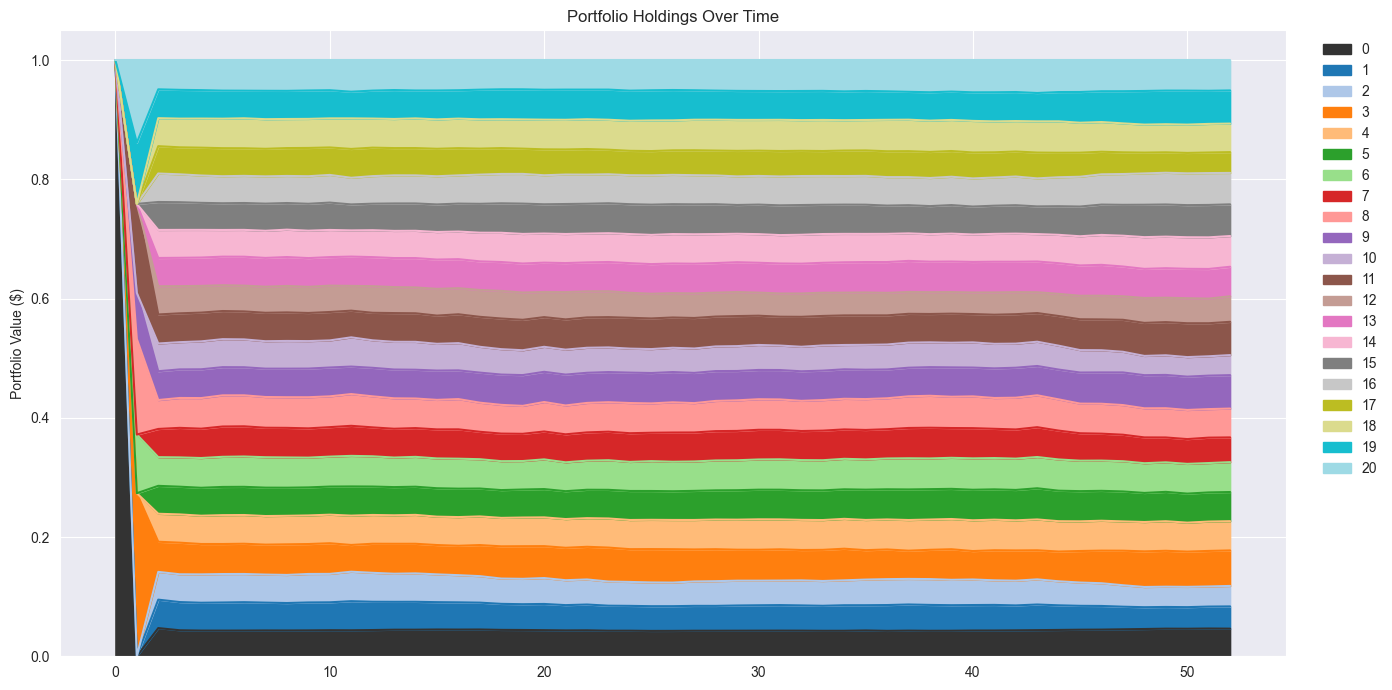

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns

# all except cash
asset_colors = sns.color_palette("tab20", market.n_assets)

# add cash color at the start
colors =  [(0.2, 0.2, 0.2)] + asset_colors

weights = df.div(df.sum(axis=1), axis=0)
weights[weights < 0] = 0

ax = weights.plot.area(
    figsize=(14, 7),
    #cmap=cmap
    color=colors
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Portfolio Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [325]:
sector_holdings = pd.DataFrame()

sector_holdings['cash'] = df[0]
df_ = df.drop(0, axis=1)

for sector in range(market.n_sectors):
    sector_holdings[sector] = df_.T.iloc[market.sectors == sector].sum(axis=0)

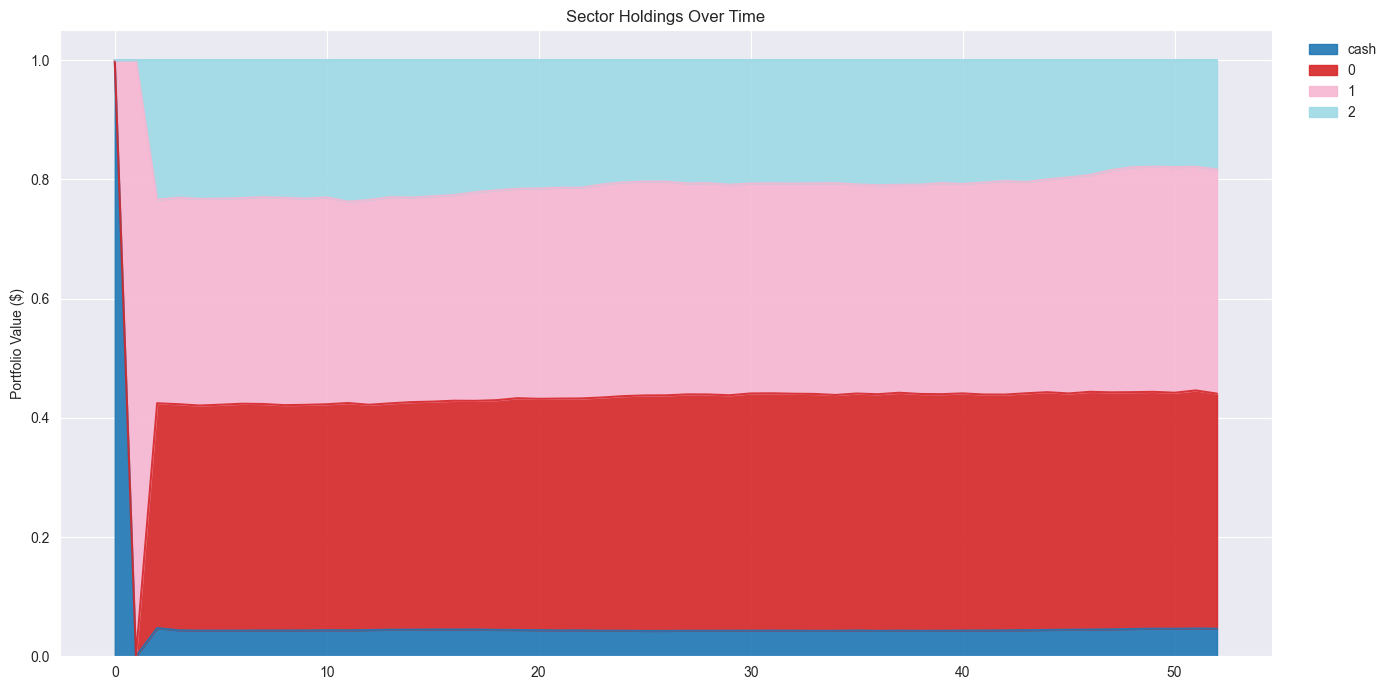

In [326]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap("tab20")

sector_weights = sector_holdings.div(df.sum(axis=1), axis=0)
sector_weights[sector_weights < 0] = 0

ax = sector_weights.plot.area(
    figsize=(14, 7),
    cmap=cmap,
    alpha=0.9
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Sector Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [327]:
market.summary()[market.summary()['sector'] == 0]

,alpha,beta,idio vols,sector,sector_coeffs,sector_vols,vol_premium
3,0.000051,0.397604,0.007577,0,0.368714,0.008429,1.144365
4,0.000054,0.336918,0.006896,0,0.356582,0.008429,1.189852
6,-0.000120,0.585180,0.012067,0,0.593226,0.008429,1.998701
12,0.000061,0.361245,0.007138,0,0.396749,0.008429,1.047352
13,0.000028,0.371033,0.008061,0,0.447021,0.008429,-1.312153
14,0.000073,0.369902,0.007894,0,0.428093,0.008429,-1.248239
15,0.000086,0.278889,0.005575,0,0.283037,0.008429,-0.932945
17,0.000125,0.471793,0.009758,0,0.519154,0.008429,1.478553


In [329]:
rm = pd.Series(market_sims[0])

In [330]:
rm = rm.pct_change()
rm = rm - rm.mean()
m_volatility = (rm**2).ewm(span=20, adjust=False).mean()
m_fast = (rm**2).ewm(span=2, adjust=False).mean()

<Axes: >

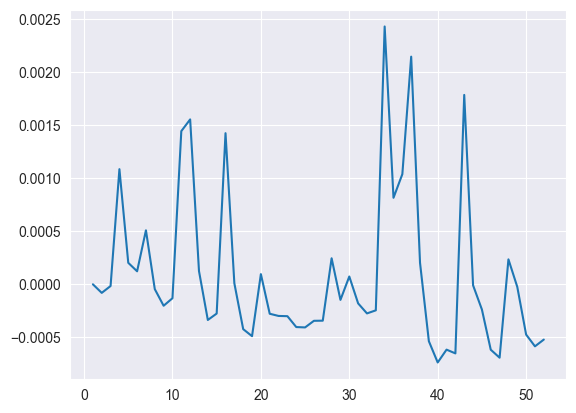

In [331]:
(m_fast - m_volatility).plot()

In [332]:
mm = pd.DataFrame(market_sims[0])

In [333]:
market_sims.std(axis=1)

array([ 7.92744096,  5.76742399,  6.28334207,  5.58207793,  9.30172454,
        6.55624765,  7.93054418,  4.24991808,  3.9404218 ,  6.46132248,
       12.1448976 ,  8.60286421, 17.27762522, 11.36599204,  4.64065137,
        5.23118861,  5.63124492,  8.12913299,  2.93044416,  6.36394711,
        5.75662444,  6.91461152,  5.51420457,  4.14064124,  5.84703176,
        7.76954537, 10.70938035,  9.55066587,  6.61402379,  6.77101077,
       15.97432457,  8.34665876,  4.79390549,  6.0217003 ,  6.71516356,
        6.03110241, 15.55685437,  2.97671431,  6.82850804,  4.0688033 ,
       16.65389802, 14.80311158, 17.22549081,  6.41164423,  6.91621402,
        9.2370413 ,  4.02085736,  9.20024497,  6.87112379,  5.49092882])

In [334]:
mm.rename(columns={0: 'market'}, inplace=True)

<Axes: >

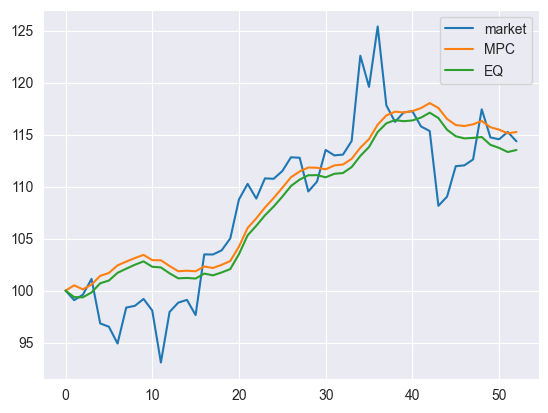

In [335]:
mm.plot(label='market', legend=True)
df.sum(axis=1).plot(label='MPC', legend=True)
eq_df.sum(axis=1).plot(label='EQ', legend=True)


In [304]:
w_ = weights.T.loc[1:]

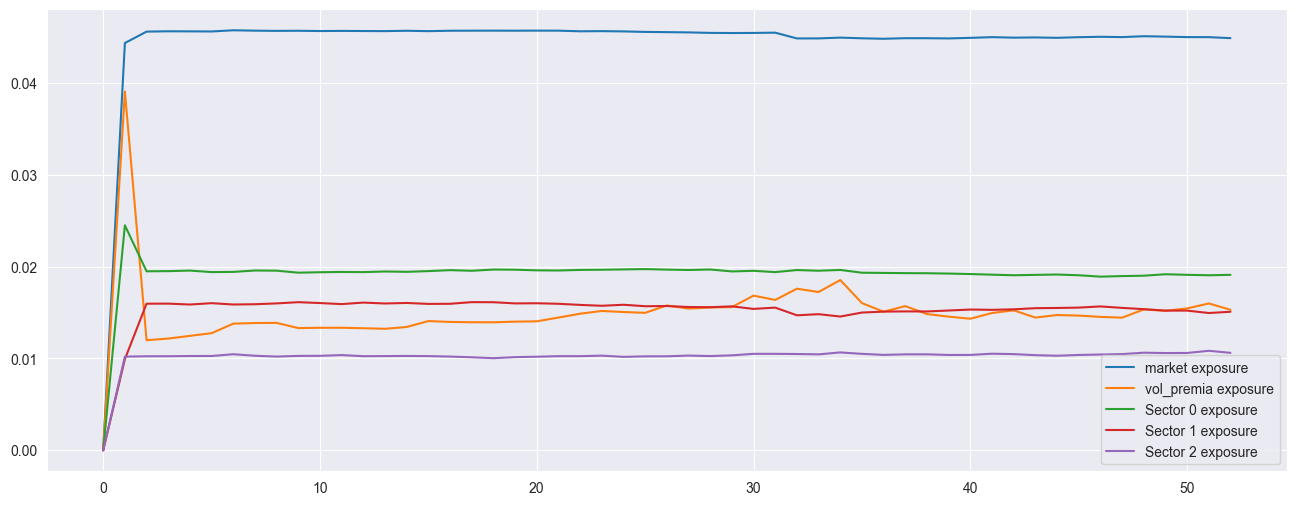

In [305]:
# Plot exposures to factors from coefficients

fig, ax = plt.subplots(1,1, figsize=(16,6))

(weights @ np.hstack([0, market.betas]) / market.betas.sum()).plot(label = 'market exposure', ax=ax)
(weights @ np.hstack([0, market.vol_premia]) / np.linalg.norm(market.vol_premia, 1)).plot(label = 'vol_premia exposure', ax=ax)

sector_exps = []
sector_scale = market.sector_coeffs.sum()

for sector in range(market.n_sectors):
    sector_mask = market.sectors == sector
    sector_exp = market.sector_coeffs[sector_mask] @ w_.iloc[sector_mask]
    sector_exps.append(sector_exp)
    (sector_exp / sector_scale).plot(label = f'Sector {sector} exposure', ax=ax)

ax.legend()

In [306]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [307]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [308]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

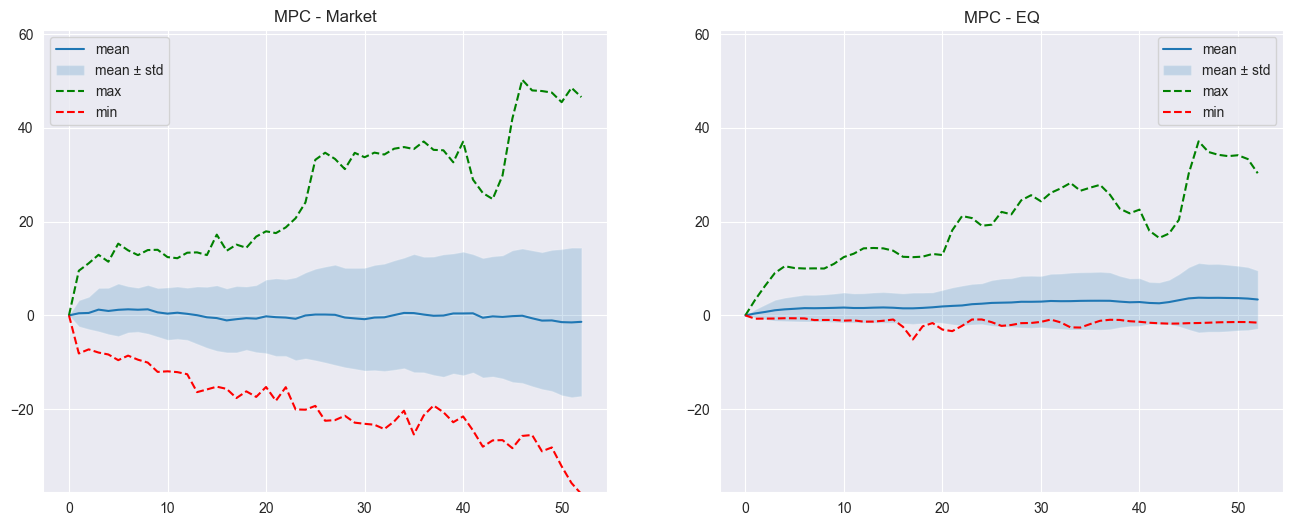

In [309]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

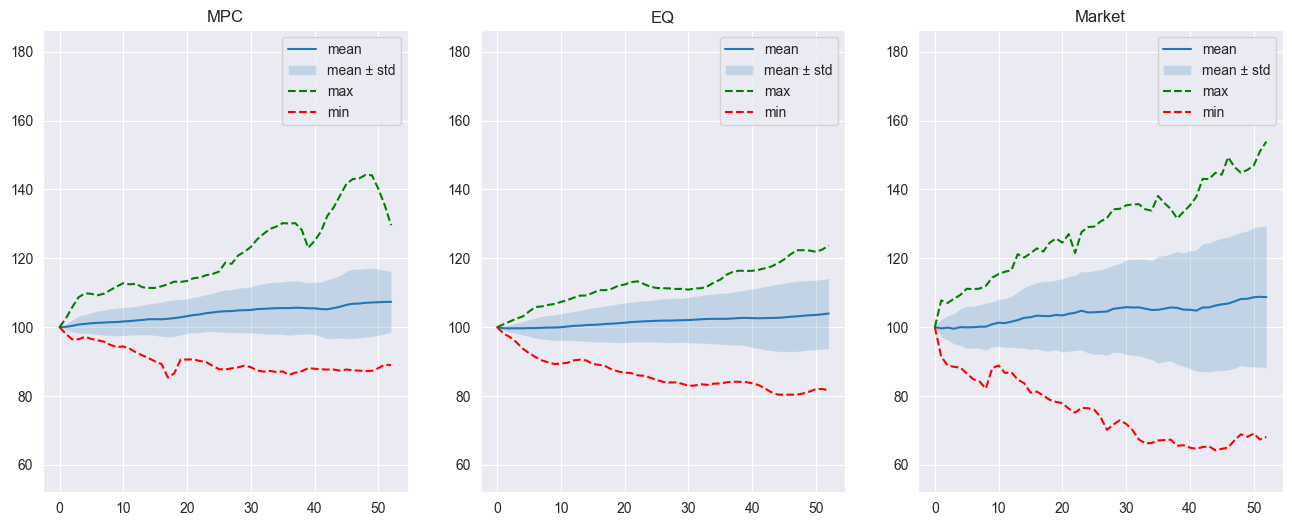

In [310]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [311]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [312]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [313]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

In [314]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [315]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,0.001254,0.001446,0.000205,0.000912,inf,0.000000
MPC beta,0.080310,0.099616,0.014088,0.051999,0.108620,1.000000
EQ alpha,0.000566,0.001752,0.000248,0.000150,inf,0.013431
EQ beta,0.056510,0.034029,0.004812,0.046839,0.066181,1.000000


In [316]:
market.base_w

array([0.35, 0.25, 0.2 , 0.2 ])

In [317]:
metrics = compute_metrics(returns, rf)
metrics

,MPC,EQ,Market
mean of mean returns,0.001337,0.000670,0.001577
std of mean returns,0.001621,0.001920,0.003649
se of mean returns,0.000229,0.000272,0.000516
ci_low of mean returns,0.000876,0.000124,0.000540
ci high of mean returns,0.001797,0.001215,0.002614
mean of sharpe ratios,0.203567,0.129984,0.078487
std of sharpe ratios,0.281490,0.367037,0.152991
se of sharpe ratios,0.039809,0.051907,0.021636
ci_low of sharpe ratios,0.123569,0.025673,0.035008
ci high of sharpe ratios,0.283566,0.234294,0.121967


In [159]:
_, _, context = load_simulation(project_root / 'datasets', 0)

In [318]:
mpc_factor_model = []
mpc_params_df = pd.DataFrame()
eq_params_df = pd.DataFrame()

for i, col in enumerate(returns['MPC'].columns):
    _, _, context = load_simulation(project_root / 'datasets', i)

    market_factor = market._calc_smooth_factor(context['market'], 'ewm', 20)

    vol_factor = market._calc_smooth_factor(context['market_vol'], 'ewm', 20)
    vol_factor = context['market_vol'].loc[vol_factor.index] - vol_factor

    sector_factors = market._calc_smooth_factor(context['sectors'], 'ewm', 20)
    
    Factors = pd.concat([market_factor, vol_factor, sector_factors], axis=1)
    Factors.columns = ['Market', 'vol_premia'] + [f"sector {j}" for j in range(market.n_sectors)]

    Factors = ((1 + Factors).resample('W-FRI')).prod()
    Factors = Factors.iloc[-52:]
    Factors.index = returns['MPC'][col].index

    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(Factors)).fit()
    mpc_factor_model.append(lm)

    mpc_params_df[i] = lm.params

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(Factors)).fit()
    eq_params_df[i] = lm.params

<Axes: >

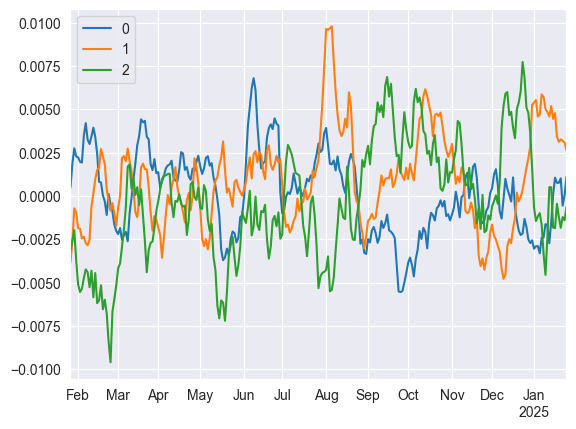

In [319]:
sector_factors[[0,1,2]].plot()

(-1.5, 1.0)

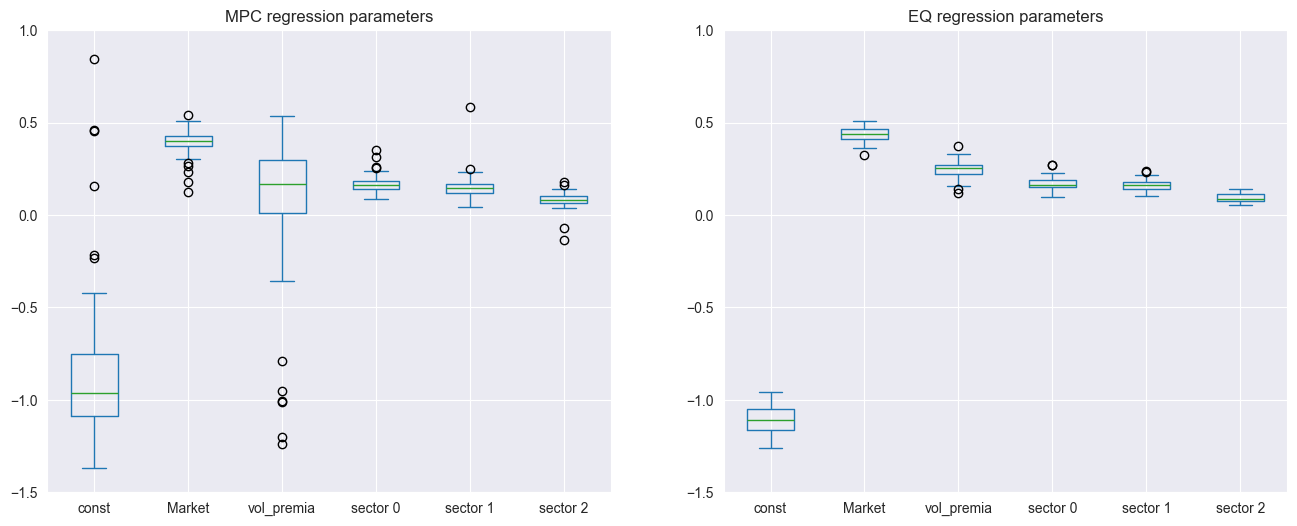

In [320]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

mpc_params_df.T.plot(kind='box', ax=ax[0])
eq_params_df.T.plot(kind='box', ax=ax[1])

ax[0].set_title('MPC regression parameters')
ax[1].set_title('EQ regression parameters')

ax[0].set_ylim(-1.5, 1.0)
ax[1].set_ylim(-1.5, 1.0)